# Task 06 — Quantization fundamentals (fake quantization lab)

**Purpose:** implement symmetric fake weight quantization on real
Qwen3-0.6B weights. Compare bit widths and group sizes. Measure the
error each choice causes.

**Lesson:** [docs/tasks/06-quantization-and-aimet.html](../docs/tasks/06-quantization-and-aimet.html)

**Environment:** local CPU, Python 3.11 via `uv`, packages from
`requirements-core.txt`. Needs `/Volumes/T9` mounted (Hugging Face
cache). No GPU needed.

**Teaching code only.** This lab quantizes weights with simple
max-based scales. Qualcomm's real recipe adds SpinQuant rotations,
AdaScale, and activation calibration (lesson section 5.6).

Run every cell in order. Then change one value in the **PARAMETERS**
cell and rerun from there.

In [1]:
import gc
import json
import os
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

# The cache location must be set before transformers is imported anywhere.
assert "transformers" not in sys.modules, (
    "transformers was already imported. Restart the kernel and run this cell first."
)
assert Path("/Volumes/T9").exists(), (
    "/Volumes/T9 is not mounted. Connect the drive, check `df -h /Volumes/T9`, rerun."
)

HF_HOME = Path("/Volumes/T9/qualcomm-edge-slm-lab/hf-home")
HF_HOME.mkdir(parents=True, exist_ok=True)
os.environ["HF_HOME"] = str(HF_HOME)

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
assert (REPO / "CLAUDE.md").exists(), f"Not inside the repo. cwd = {Path.cwd()}"
RESULTS = REPO / "results"
RESULTS.mkdir(exist_ok=True)

import matplotlib.pyplot as plt
import torch

torch.manual_seed(0)

CHECKS = {}  # filled by later cells, reported by the final summary cell

print("HF cache   :", os.environ["HF_HOME"])
print("results dir:", RESULTS)
print("torch      :", torch.__version__)
print("setup ok")

HF cache   : /Volumes/T9/qualcomm-edge-slm-lab/hf-home
results dir: /Users/chayut/projects/qualcomm-edge-slm-lab/results
torch      : 2.8.0
setup ok


## Part 1 — Real weights and one real activation

Load Qwen3-0.6B in float32 and keep two weight matrices from layer 0:

- `q_proj.weight`, shape `(2048, 1024)` — attention query projection.
- `down_proj.weight`, shape `(1024, 3072)` — MLP down projection.

A forward hook also captures the real activation entering `q_proj`
for a short prompt. We quantize weights later and measure how much
the layer *output* changes on this real input. The full model is
freed right after — only the tensors stay.

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen3-0.6B"

t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32,
    attn_implementation="eager",
)
model.eval()
print(f"loaded {MODEL_ID} in {time.time() - t0:.1f} s")

layer0 = model.model.layers[0]
W_qproj = layer0.self_attn.q_proj.weight.detach().clone()
W_down = layer0.mlp.down_proj.weight.detach().clone()

# Capture the real input of q_proj with a forward hook.
captured = {}

def grab_input(module, args, output):
    captured["x"] = args[0].detach().clone()

hook = layer0.self_attn.q_proj.register_forward_hook(grab_input)
prompt = "The capital of Thailand is"
ids = tokenizer(prompt, return_tensors="pt")
with torch.no_grad():
    model(**ids)
hook.remove()

X = captured["x"].reshape(-1, W_qproj.shape[1])  # (tokens, 1024)

assert W_qproj.shape == (2048, 1024), W_qproj.shape
assert W_down.shape == (1024, 3072), W_down.shape
assert X.shape[1] == 1024 and X.shape[0] >= 4, X.shape
CHECKS["weights_loaded"] = True
CHECKS["activation_captured"] = True

del model
gc.collect()

print("W_qproj:", tuple(W_qproj.shape))
print("W_down :", tuple(W_down.shape))
print("X      :", tuple(X.shape), "(real activation entering q_proj)")
print("model freed; tensors kept")

/Users/chayut/projects/qualcomm-edge-slm-lab/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded Qwen/Qwen3-0.6B in 4.9 s
W_qproj: (2048, 1024)
W_down : (1024, 3072)
X      : (5, 1024) (real activation entering q_proj)
model freed; tensors kept


## Part 2 — The quantizer

This is the whole formula from lesson section 5.1, as one function.

`group_size` decides who shares a scale:

- `"per_tensor"` — one scale for the whole matrix.
- `"per_channel"` — one scale per output row.
- an integer — blocks of that many inputs inside each row.

The self-test reproduces the worked example from lesson section 6:
at 4 bits, one outlier erases its per-tensor neighbors; grouped, they
survive.

In [3]:
def fake_quantize_symmetric(w, num_bits, group_size):
    """Symmetric fake quantization of a 2-D weight tensor.

    Returns (w_fq, scales): the snapped float weights and the scale
    used by each group.
    """
    assert w.dim() == 2, "expects a 2-D weight matrix"
    assert 2 <= num_bits <= 16, num_bits
    qmax = 2 ** (num_bits - 1) - 1
    if group_size == "per_tensor":
        groups = w.reshape(1, -1)
    elif group_size == "per_channel":
        groups = w.reshape(w.shape[0], -1)
    else:
        assert w.shape[1] % group_size == 0, (
            f"group_size {group_size} must divide input dim {w.shape[1]}"
        )
        groups = w.reshape(-1, group_size)
    scales = groups.abs().amax(dim=1, keepdim=True) / qmax
    scales = torch.clamp(scales, min=1e-12)
    q = torch.clamp(torch.round(groups / scales), -qmax, qmax)
    w_fq = (q * scales).reshape(w.shape)
    return w_fq, scales.flatten()


# --- Self-test 1: the worked example, per-tensor, 4 bits ---
w_hand = torch.tensor([[0.02, -0.01, 0.03, 1.50]])
w_fq, s = fake_quantize_symmetric(w_hand, num_bits=4, group_size="per_tensor")
print("outlier group  :", w_fq.flatten().tolist(), " scale =", round(float(s[0]), 7))
assert torch.allclose(w_fq, torch.tensor([[0.0, 0.0, 0.0, 1.5]])), w_fq
# The three normal weights were erased to exactly 0. 100% error.

# --- Self-test 2: outlier isolated in its own group ---
w_small = torch.tensor([[0.02, -0.01, 0.03]])
w_fq2, s2 = fake_quantize_symmetric(w_small, num_bits=4, group_size="per_tensor")
print("no-outlier group:", [round(v, 4) for v in w_fq2.flatten().tolist()],
      " scale =", round(float(s2[0]), 7))
q_codes = torch.round(w_small / s2)
assert q_codes.flatten().tolist() == [5.0, -2.0, 7.0], q_codes
# Same bits, tiny error, exactly the lesson numbers.

# --- Self-test 3: a b-bit grid has at most 2*qmax+1 distinct levels ---
w_rand = torch.randn(8, 64)
w_fq3, _ = fake_quantize_symmetric(w_rand, num_bits=3, group_size="per_channel")
for row in w_fq3:
    assert row.unique().numel() <= 2 * (2 ** 2 - 1) + 1  # <= 15 levels at 3 bits

CHECKS["quantizer_self_test"] = True
print("quantizer self-test ok")

outlier group  : [0.0, -0.0, 0.0, 1.5]  scale = 0.2142857
no-outlier group: [0.0214, -0.0086, 0.03]  scale = 0.0042857
quantizer self-test ok


## Part 3 — What real weights look like

Histogram of every `down_proj` value, log-scale y axis.

**Inspect:** the thin tails far from zero. Those few values are the
outliers. With one per-tensor scale, the largest of them sets the grid
for all 3,145,728 weights.

count      : 3,145,728
std        : 0.02624
max |w|    : 0.41797
max/std    : 15.9x


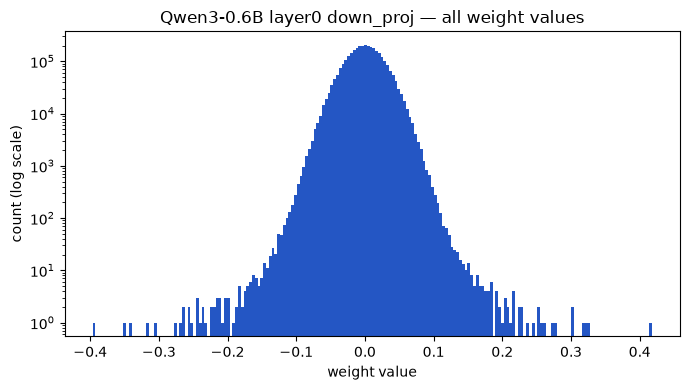

saved: /Users/chayut/projects/qualcomm-edge-slm-lab/results/06_weight_histogram.png


In [4]:
vals = W_down.flatten()
print(f"count      : {vals.numel():,}")
print(f"std        : {vals.std():.5f}")
print(f"max |w|    : {vals.abs().max():.5f}")
print(f"max/std    : {vals.abs().max() / vals.std():.1f}x")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(vals.numpy(), bins=200, log=True, color="#2456c4")
ax.set_xlabel("weight value")
ax.set_ylabel("count (log scale)")
ax.set_title("Qwen3-0.6B layer0 down_proj — all weight values")
fig.tight_layout()
hist_path = RESULTS / "06_weight_histogram.png"
fig.savefig(hist_path, dpi=120)
plt.show()
print("saved:", hist_path)
# Inspect: how many standard deviations out does the farthest value sit?

## Part 4 — The snap, up close

Take one real row of `down_proj`, quantize it at 4 bits per-channel,
and plot the first 64 weights before and after.

**Inspect:** the quantized dots sit on a small set of horizontal
levels — the 4-bit grid. Count how many distinct levels the 64 dots
actually use.

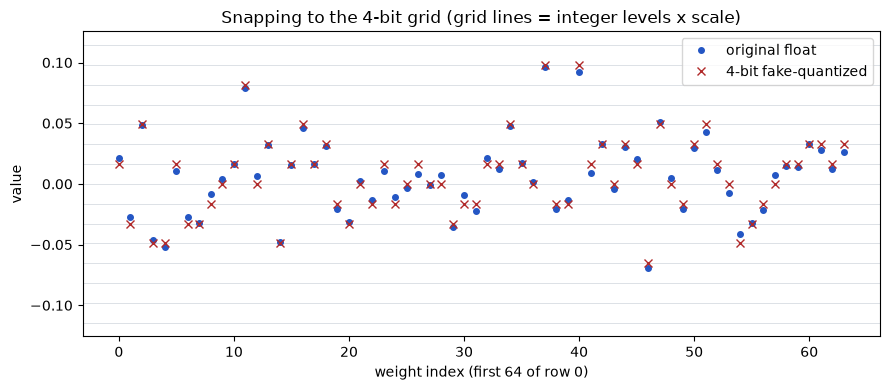

distinct levels used by these 64 weights: 10 (max possible at 4 bits: 15)
saved: /Users/chayut/projects/qualcomm-edge-slm-lab/results/06_staircase.png


In [5]:
row = W_down[0:1, :]  # keep 2-D: (1, 3072)
row_fq, row_s = fake_quantize_symmetric(row, num_bits=4, group_size="per_channel")
n_show = 64
orig = row[0, :n_show].numpy()
snap = row_fq[0, :n_show].numpy()

fig, ax = plt.subplots(figsize=(9, 4))
s0 = float(row_s[0])
for k in range(-7, 8):
    ax.axhline(k * s0, color="#d7dce2", linewidth=0.6, zorder=0)
ax.plot(orig, "o", markersize=4, label="original float", color="#2456c4")
ax.plot(snap, "x", markersize=6, label="4-bit fake-quantized", color="#b02a2a")
ax.set_xlabel("weight index (first 64 of row 0)")
ax.set_ylabel("value")
ax.set_title("Snapping to the 4-bit grid (grid lines = integer levels x scale)")
ax.legend()
fig.tight_layout()
stair_path = RESULTS / "06_staircase.png"
fig.savefig(stair_path, dpi=120)
plt.show()

n_levels = len(set(snap.tolist()))
print(f"distinct levels used by these 64 weights: {n_levels} (max possible at 4 bits: 15)")
print("saved:", stair_path)

## PARAMETERS — yours to change

Run the whole notebook once as-is. Then change one of these and rerun
from this cell to the end. The results file keeps every run.

Ideas: add `6` to `BIT_WIDTHS`, or add `16` to `GROUP_SIZES`, or drop
`8` to zoom in on the low-bit region.

Keep `"per_tensor"` and `"per_channel"` in `GROUP_SIZES`, plus at
least one integer — the checks compare across them. Integer group
sizes must divide both 1024 and 3072 (so: 2, 4, 8, 16, 32, 64, 128,
256, 512).

In [10]:
BIT_WIDTHS = [2, 3, 4, 6, 8, 16]        # <-- change me (integers, 2..16)
GROUP_SIZES = ["per_tensor", "per_channel", 128, 32, 16, 8]   # <-- change me

assert all(isinstance(b, int) and 2 <= b <= 16 for b in BIT_WIDTHS), BIT_WIDTHS
assert len(BIT_WIDTHS) >= 2, "keep at least two bit widths to compare"
assert "per_tensor" in GROUP_SIZES and "per_channel" in GROUP_SIZES, (
    "keep per_tensor and per_channel; the checks compare against them"
)
int_groups = [g for g in GROUP_SIZES if isinstance(g, int)]
assert int_groups, "keep at least one integer group size"
for g in int_groups:
    assert 1024 % g == 0 and 3072 % g == 0, (
        f"group size {g} must divide 1024 and 3072"
    )
print("BIT_WIDTHS :", BIT_WIDTHS)
print("GROUP_SIZES:", GROUP_SIZES)

BIT_WIDTHS : [2, 3, 4, 6, 8, 16]
GROUP_SIZES: ['per_tensor', 'per_channel', 128, 32, 16, 8]


## Part 5 — The sweep

Every (bit width, grouping) pair, on both real matrices.

Two error numbers:

- **weight relative error** — `norm(W - W_fq) / norm(W)`.
- **output relative error** (q_proj only) — same formula on
  `Y = X @ W.T`, using the real captured activation.

**Inspect:** in `06_error_vs_bits.png`, the vertical gap between the
grouping lines. In `06_error_vs_group.png`, which matrix gains more
from finer groups. In the table, output error should move with weight
error.

weight     bits     grouping  w_rel_err  out_rel_err
q_proj        2   per_tensor    0.99801      0.89820
q_proj        2  per_channel    0.88570      0.63575
q_proj        2          128    0.77434      0.48242
q_proj        2           32    0.66026      0.37913
q_proj        2           16    0.58600      0.33044
q_proj        2            8    0.49673      0.27810
q_proj        3   per_tensor    0.96399      0.67408
q_proj        3  per_channel    0.38493      0.21739
q_proj        3          128    0.28936      0.16656
q_proj        3           32    0.23327      0.13314
q_proj        3           16    0.20321      0.11470
q_proj        3            8    0.16998      0.09707
q_proj        4   per_tensor    0.74808      0.44669
q_proj        4  per_channel    0.16685      0.09449
q_proj        4          128    0.12417      0.07440
q_proj        4           32    0.09987      0.05789
q_proj        4           16    0.08700      0.04960
q_proj        4            8    0.07277      0

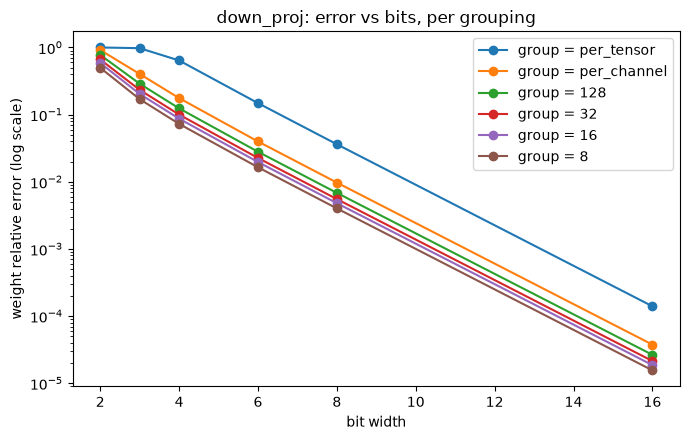

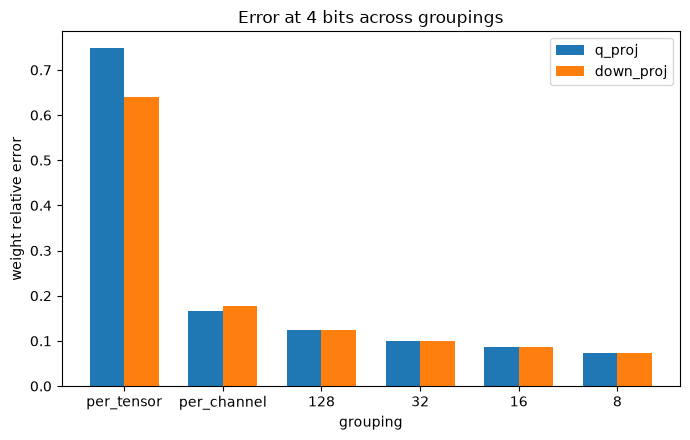

saved: /Users/chayut/projects/qualcomm-edge-slm-lab/results/06_error_vs_bits.png
saved: /Users/chayut/projects/qualcomm-edge-slm-lab/results/06_error_vs_group.png
saved: /Users/chayut/projects/qualcomm-edge-slm-lab/results/06_quant_error.json (2 run key(s))


In [11]:
weights = {"q_proj": W_qproj, "down_proj": W_down}
records = {}

print(f"{'weight':<10} {'bits':>4} {'grouping':>12} {'w_rel_err':>10} {'out_rel_err':>12}")
for name, W in weights.items():
    Y = X @ W.T if name == "q_proj" else None
    for b in sorted(BIT_WIDTHS):
        for g in GROUP_SIZES:
            W_fq, scales = fake_quantize_symmetric(W, b, g)
            w_err = float((W - W_fq).norm() / W.norm())
            entry = {"weight_rel_error": w_err, "num_scales": int(scales.numel())}
            out_str = ""
            if Y is not None:
                Y_fq = X @ W_fq.T
                o_err = float((Y - Y_fq).norm() / Y.norm())
                entry["output_rel_error"] = o_err
                out_str = f"{o_err:12.5f}"
            records[f"{name}|bits={b}|group={g}"] = entry
            print(f"{name:<10} {b:>4} {str(g):>12} {w_err:10.5f} {out_str}")

REF_BITS = 4 if 4 in BIT_WIDTHS else sorted(BIT_WIDTHS)[len(BIT_WIDTHS) // 2]

# Plot 1: error vs bit width, one line per grouping (down_proj)
fig, ax = plt.subplots(figsize=(7, 4.5))
for g in GROUP_SIZES:
    ys = [records[f"down_proj|bits={b}|group={g}"]["weight_rel_error"]
          for b in sorted(BIT_WIDTHS)]
    ax.plot(sorted(BIT_WIDTHS), ys, marker="o", label=f"group = {g}")
ax.set_yscale("log")
ax.set_xlabel("bit width")
ax.set_ylabel("weight relative error (log scale)")
ax.set_title("down_proj: error vs bits, per grouping")
ax.legend()
fig.tight_layout()
bits_path = RESULTS / "06_error_vs_bits.png"
fig.savefig(bits_path, dpi=120)
plt.show()

# Plot 2: error vs grouping at REF_BITS, both matrices
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = [str(g) for g in GROUP_SIZES]
xs = range(len(GROUP_SIZES))
width = 0.35
for i, name in enumerate(weights):
    ys = [records[f"{name}|bits={REF_BITS}|group={g}"]["weight_rel_error"]
          for g in GROUP_SIZES]
    ax.bar([x + i * width for x in xs], ys, width, label=name)
ax.set_xticks([x + width / 2 for x in xs])
ax.set_xticklabels(labels)
ax.set_xlabel("grouping")
ax.set_ylabel("weight relative error")
ax.set_title(f"Error at {REF_BITS} bits across groupings")
ax.legend()
fig.tight_layout()
group_path = RESULTS / "06_error_vs_group.png"
fig.savefig(group_path, dpi=120)
plt.show()

# Save every number, keyed by this run's configuration. Reruns with a
# changed parameter add a new key instead of overwriting.
err_path = RESULTS / "06_quant_error.json"
all_runs = json.loads(err_path.read_text()) if err_path.exists() else {}
run_key = f"bits={sorted(BIT_WIDTHS)}|groups={GROUP_SIZES}"
all_runs[run_key] = {
    "records": records,
    "ref_bits": REF_BITS,
    "saved_at": datetime.now(timezone.utc).isoformat(),
}
err_path.write_text(json.dumps(all_runs, indent=2))

print("saved:", bits_path)
print("saved:", group_path)
print("saved:", err_path, f"({len(all_runs)} run key(s))")

## Part 6 — Why rotations help (SpinQuant idea, illustration only)

Multiply `down_proj` by a random orthogonal matrix `Q`
(`Q @ Q.T = I`). The matrix norm cannot change, but the values mix:
the outlier's energy spreads across many entries, so `max(|w|)`
drops, the per-tensor scale drops, and the 4-bit error drops.

This is **not SpinQuant** — the real method picks specific rotation
places (R2 on the attention value path, R3 as Hadamard ops on
activations) and inserts the inverse so the network stays identical.
This cell only shows the mechanism.

In [12]:
torch.manual_seed(0)
n = W_down.shape[1]
Qr, _ = torch.linalg.qr(torch.randn(n, n))
W_rot = W_down @ Qr

assert torch.allclose(W_rot.norm(), W_down.norm(), rtol=1e-3)  # rotation keeps norm (float32 rounding)

def per_tensor_err(W, bits):
    W_fq, _ = fake_quantize_symmetric(W, bits, "per_tensor")
    return float((W - W_fq).norm() / W.norm())

max_before = float(W_down.abs().max())
max_after = float(W_rot.abs().max())
err_before = per_tensor_err(W_down, 4)
err_after = per_tensor_err(W_rot, 4)

print(f"max |w|  before rotation: {max_before:.5f}")
print(f"max |w|  after  rotation: {max_after:.5f}")
print(f"4-bit per-tensor error before: {err_before:.5f}")
print(f"4-bit per-tensor error after : {err_after:.5f}")

CHECKS["rotation_demo_ran"] = True
CHECKS["rotation_reduced_max_abs"] = bool(max_after < max_before)
# Inspect: same matrix, same bits, same grouping — only the numbers
# were rotated, and the error already moved.

max |w|  before rotation: 0.41797
max |w|  after  rotation: 0.21173
4-bit per-tensor error before: 0.64018
4-bit per-tensor error after : 0.33275


## Summary — automated checks

Reports every check and every saved artifact. All checks must pass.
If one fails, the message names the cell to look at.

In [13]:
bits_sorted = sorted(BIT_WIDTHS)

# More bits => less error (down_proj, per-tensor, strictly decreasing)
errs = [records[f"down_proj|bits={b}|group=per_tensor"]["weight_rel_error"]
        for b in bits_sorted]
CHECKS["error_decreases_with_bits"] = all(
    errs[i] > errs[i + 1] for i in range(len(errs) - 1)
)

# Finer grouping => less error at REF_BITS (down_proj)
e_tensor = records[f"down_proj|bits={REF_BITS}|group=per_tensor"]["weight_rel_error"]
e_channel = records[f"down_proj|bits={REF_BITS}|group=per_channel"]["weight_rel_error"]
e_finest = records[f"down_proj|bits={REF_BITS}|group={min(int_groups)}"]["weight_rel_error"]
CHECKS["grouping_helps"] = bool(e_finest < e_channel < e_tensor)

# Output error follows weight error (q_proj, most vs fewest bits)
o_low = records[f"q_proj|bits={bits_sorted[0]}|group=per_tensor"]["output_rel_error"]
o_high = records[f"q_proj|bits={bits_sorted[-1]}|group=per_tensor"]["output_rel_error"]
CHECKS["output_error_tracks_bits"] = bool(o_high < o_low)

artifacts = [
    RESULTS / "06_weight_histogram.png",
    RESULTS / "06_staircase.png",
    RESULTS / "06_error_vs_bits.png",
    RESULTS / "06_error_vs_group.png",
    RESULTS / "06_quant_error.json",
]
CHECKS["plots_and_results_saved"] = all(p.exists() for p in artifacts)

n_run_keys = len(json.loads((RESULTS / "06_quant_error.json").read_text()))
CHECKS["parameter_change_recorded"] = n_run_keys >= 2  # False until your rerun

print("CHECKS")
for k, v in CHECKS.items():
    print(f"  {'PASS' if v else 'FAIL':<4} {k}")
print()
print(f"run keys in 06_quant_error.json: {n_run_keys}")
print("artifacts:")
for p in artifacts:
    print("  ", p)

required = [k for k in CHECKS if k not in
            ("parameter_change_recorded", "rotation_reduced_max_abs")]
assert all(CHECKS[k] for k in required), (
    "a required check failed — see the FAIL line above"
)
if not CHECKS["parameter_change_recorded"]:
    print()
    print("NOTE: change BIT_WIDTHS or GROUP_SIZES and rerun from the "
          "PARAMETERS cell — the gate needs at least two run keys.")

summary = {
    "task": 6,
    "checks": CHECKS,
    "run_keys": n_run_keys,
    "bit_widths": BIT_WIDTHS,
    "group_sizes": [str(g) for g in GROUP_SIZES],
    "artifacts": [str(p.relative_to(REPO)) for p in artifacts],
    "saved_at": datetime.now(timezone.utc).isoformat(),
}
(RESULTS / "06_summary.json").write_text(json.dumps(summary, indent=2))
print()
print("saved:", RESULTS / "06_summary.json")

CHECKS
  PASS weights_loaded
  PASS activation_captured
  PASS quantizer_self_test
  PASS rotation_demo_ran
  PASS rotation_reduced_max_abs
  PASS error_decreases_with_bits
  PASS grouping_helps
  PASS output_error_tracks_bits
  PASS plots_and_results_saved
  PASS parameter_change_recorded

run keys in 06_quant_error.json: 2
artifacts:
   /Users/chayut/projects/qualcomm-edge-slm-lab/results/06_weight_histogram.png
   /Users/chayut/projects/qualcomm-edge-slm-lab/results/06_staircase.png
   /Users/chayut/projects/qualcomm-edge-slm-lab/results/06_error_vs_bits.png
   /Users/chayut/projects/qualcomm-edge-slm-lab/results/06_error_vs_group.png
   /Users/chayut/projects/qualcomm-edge-slm-lab/results/06_quant_error.json

saved: /Users/chayut/projects/qualcomm-edge-slm-lab/results/06_summary.json


## Done

1. If `parameter_change_recorded` is still FALSE: change
   `BIT_WIDTHS` or `GROUP_SIZES`, rerun from the PARAMETERS cell.
2. Save this notebook with its outputs (Cmd+S).
3. Say `Review my current task.`